# Proceso Transformación


## Importación de Dependencias

In [47]:
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()
from sqlalchemy import create_engine

## Fase de Extracción de Datos

En esta fase se obtienen los datos desde las fuentes definidas para el proyecto:

- **Base de datos PostgreSQL:** catálogos de entidad, sexo, nacionalidad, origen, resultado y respuesta binaria.
- **Archivos JSON:** catálogos de sector y tipo de paciente.
- **Archivo CSV:** registros generales de casos COVID-19 en México.

### Manejo de Variables de Entorno

In [48]:
DB_USER = os.getenv("POSTGRES_USER")
DB_PASSWORD = os.getenv("POSTGRES_PASSWORD")
DB_NAME = os.getenv("POSTGRES_DB")
DB_HOST = os.getenv("POSTGRES_HOST")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")


### Seguridad y variables de entorno

Las credenciales y parámetros de conexión se cargan desde el archivo `.env` mediante `python-dotenv`. Esta práctica evita exponer usuarios y contraseñas en el código fuente y permite reutilizar el mismo notebook en distintos entornos sin modificar la lógica de transformación.

## Cargando nuestra Base de Datos

In [49]:
engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

df_entidades = pd.read_sql("select * from cat_entidad_federativa", engine)
df_nacionalidad = pd.read_sql("select * from cat_nacionalidad", engine)
df_origen = pd.read_sql("select * from cat_tipo_usmer", engine)
df_resultado = pd.read_sql("select * from cat_resultado_laboratorio", engine)
df_sexo = pd.read_sql("select * from cat_sexo", engine)
df_respuesta = pd.read_sql("select * from cat_respuesta_binaria", engine)

## Carga de Datos Tipo Json

In [50]:
df_sector = pd.read_json("data/5 Sector.json")
df_tipopaciente = pd.read_json("data/8 Tipo_Paciente.json")

## Carga de Datos tipo CSV

In [51]:
df_covidgeneral = pd.read_csv("data/covid-19_general_MX.csv")

## Análisis de Cada DataFrame

El objetivo de este análisis es identificar la estructura, calidad y relaciones entre las fuentes de datos. Esta evaluación orienta las reglas de limpieza, la selección de columnas y la integración posterior con el modelo analítico.

### Base de Datos Postgres

In [52]:
catalogos = {
    "entidades": df_entidades,
    "nacionalidad": df_nacionalidad,
    "origen": df_origen,
    "resultado": df_resultado,
    "sexo": df_sexo,
    "respuesta": df_respuesta,
}

resumen_catalogos = []
for nombre, df in catalogos.items():
    resumen_catalogos.append({
        "catalogo": nombre,
        "registros": len(df),
        "columnas": df.shape[1],
        "nulos": int(df.isnull().sum().sum()),
        "duplicados": int(df.duplicated().sum()),
    })

pd.DataFrame(resumen_catalogos)


,catalogo,registros,columnas,nulos,duplicados
0,entidades,36,3,0,0
1,nacionalidad,3,2,0,0
2,origen,3,2,0,0
3,resultado,3,2,0,0
4,sexo,3,2,0,0
5,respuesta,5,2,0,0


Los catálogos en PostgreSQL son tablas pequeñas con claves numéricas estables. No presentan nulos ni duplicados relevantes y funcionan como dimensiones para enriquecer la tabla de hechos mediante `merge`.

### Datos Json

In [53]:
resumen_json = []
for nombre, df in {"sector": df_sector, "tipo_paciente": df_tipopaciente}.items():
    resumen_json.append({
        "archivo": nombre,
        "registros": len(df),
        "columnas": ", ".join(df.columns),
        "nulos": int(df.isnull().sum().sum()),
        "duplicados": int(df.duplicated().sum()),
    })

pd.DataFrame(resumen_json)


,archivo,registros,columnas,nulos,duplicados
0,sector,14,"clave, descripcion",0,0
1,tipo_paciente,3,"clave, descripcion",0,0


Los archivos JSON contienen las columnas `clave` y `descripcion`. Corresponden a los catálogos de sector institucional y tipo de paciente utilizados por el CSV principal.

### Archivo de Datos CSV

El archivo `covid-19_general_MX.csv` contiene la tabla de hechos del proyecto. En esta etapa se revisa la estructura y la calidad del dato **en su estado original**, antes de aplicar las reglas de transformación.

En este dataset, los valores faltantes no siempre aparecen como nulos: la Secretaría de Salud utiliza códigos oficiales como `97`, `98`, `99` y la fecha `9999-99-99` para indicar "no aplica", "se ignora" o "no especificado".


In [54]:
print(f"Registros: {len(df_covidgeneral):,}")
print(f"Columnas: {df_covidgeneral.shape[1]}")
print(f"Memoria aproximada: {df_covidgeneral.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

df_covidgeneral.head()


Registros: 879,608
Columnas: 26
Memoria aproximada: 302.8 MB


,Unnamed: 0,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,...,INMUSUPR,HIPERTENSION,OTRA_CON,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,OTRO_CASO,RESULTADO,UCI
0,0,4,9,2,9,1,2020-03-23,2020-03-22,9999-99-99,97,...,2,2,2,2,2,2,2,99,1,97
1,1,4,9,2,9,2,2020-04-13,2020-04-04,9999-99-99,2,...,2,2,2,2,1,2,2,99,1,2
2,2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,...,2,1,2,2,1,2,2,99,1,2
3,3,4,30,1,30,1,2020-04-27,2020-04-17,9999-99-99,97,...,2,2,1,2,2,2,2,99,1,97
4,4,3,15,2,15,2,2020-06-06,2020-06-01,9999-99-99,2,...,2,2,2,2,2,2,2,1,1,2


In [55]:
codigos_especiales = [97, 98, 99]
columnas_binarias = [
    "INTUBADO", "NEUMONIA", "DIABETES", "EPOC", "ASMA", "INMUSUPR",
    "HIPERTENSION", "OTRA_CON", "CARDIOVASCULAR", "OBESIDAD",
    "RENAL_CRONICA", "TABAQUISMO", "UCI",
]

resumen_csv = pd.DataFrame([
    {"indicador": "Total de registros", "valor": f"{len(df_covidgeneral):,}"},
    {"indicador": "Total de columnas", "valor": df_covidgeneral.shape[1]},
    {"indicador": "Registros duplicados", "valor": int(df_covidgeneral.duplicated().sum())},
    {
        "indicador": "FECHA_DEF con codigo 9999-99-99",
        "valor": int((df_covidgeneral["FECHA_DEF"] == "9999-99-99").sum()),
    },
    {
        "indicador": "Interpretacion FECHA_DEF 9999-99-99",
        "valor": "Sin fecha de defuncion registrada (codigo oficial del dataset)",
    },
    {
        "indicador": "Columna Unnamed: 0",
        "valor": "Presente" if "Unnamed: 0" in df_covidgeneral.columns else "No presente",
    },
    {
        "indicador": "Edad promedio",
        "valor": round(df_covidgeneral["EDAD"].mean(), 2),
    },
    {
        "indicador": "Registros con codigos 97/98/99 en variables binarias",
        "valor": int(df_covidgeneral[columnas_binarias].isin(codigos_especiales).any(axis=1).sum()),
    },
])

resumen_csv


,indicador,valor
0,Total de registros,"879,608"
1,Total de columnas,26
2,Registros duplicados,0
3,FECHA_DEF con codigo 9999-99-99,825207
4,Interpretacion FECHA_DEF 9999-99-99,Sin fecha de defuncion registrada (codigo ofic...
5,Columna Unnamed: 0,Presente
6,Edad promedio,42.55
7,Registros con codigos 97/98/99 en variables bi...,708280


**Hallazgos del CSV:**
- La fuente contiene aproximadamente 879 mil registros y 26 columnas.
- No se observan nulos explícitos porque el dataset utiliza códigos especiales en lugar de valores vacíos.
- `FECHA_DEF = 9999-99-99` representa casos sin defunción registrada, no un error de captura.
- Las variables clínicas están codificadas numéricamente y requieren estandarización en la etapa de transformación.
- La columna `Unnamed: 0` será eliminada por no aportar al análisis.


### Relaciones entre fuentes

| Campo en hechos | Fuente destino | Campo de unión |
|---|---|---|
| `SECTOR` | `df_sector` | `clave` |
| `TIPO_PACIENTE` | `df_tipopaciente` | `clave` |
| `ENTIDAD_RES` | `df_entidades` | `clave_entidad` |
| `SEXO` | `df_sexo` | `clave` |
| `NACIONALIDAD` | `df_nacionalidad` | `clave` |
| `RESULTADO` | `df_resultado` | `clave` |
| Variables binarias | `df_respuesta` | `clave` |

## Inicio del Proceso de Transformación de los Datos

En esta etapa se aplican reglas de negocio y criterios analíticos para preparar la información del modelo dimensional. El proceso incluye funciones de limpieza, transformación de tipos, generación de identificadores e integración entre tablas de hechos y dimensiones.

## Funciones de Limpieza y Transformación

In [57]:
MAPEO_BINARIO = {
    1: "SI",
    2: "NO",
    97: "NO APLICA",
    98: "SE IGNORA",
    99: "NO ESPECIFICADO",
}


def limpiar_fecha(valor):
    """Convierte codigos oficiales de fecha no aplicable a valor nulo."""
    if pd.isna(valor):
        return None
    texto = str(valor).strip()
    if texto in {"", "9999-99-99", "NaT"}:
        return None
    return texto


def normalizar_codigo_binario(valor):
    """Traduce codigos oficiales 1/2/97/98/99 a descripcion legible."""
    if pd.isna(valor):
        return "NO ESPECIFICADO"
    try:
        clave = int(valor)
    except (TypeError, ValueError):
        return "NO ESPECIFICADO"
    return MAPEO_BINARIO.get(clave, "NO ESPECIFICADO")


def validar_edad(edad):
    """Valida edad y genera grupo etario para analisis."""
    if pd.isna(edad):
        return False, "SIN EDAD"
    try:
        edad_num = int(edad)
    except (TypeError, ValueError):
        return False, "SIN EDAD"
    if edad_num < 0 or edad_num > 120:
        return False, "SIN EDAD"
    if edad_num <= 17:
        grupo = "0-17"
    elif edad_num <= 39:
        grupo = "18-39"
    elif edad_num <= 59:
        grupo = "40-59"
    else:
        grupo = "60+"
    return True, grupo


def agregar_id_secuencial(df, nombre_columna):
    """Genera identificador numerico secuencial para integracion entre tablas."""
    df = df.copy()
    df[nombre_columna] = df.index + 1
    return df


## Transformación de Catálogos PostgreSQL

In [58]:
df_entidades = agregar_id_secuencial(df_entidades, "id_entidad")
df_nacionalidad = agregar_id_secuencial(df_nacionalidad, "id_nacionalidad")
df_origen = agregar_id_secuencial(df_origen, "id_origen")
df_resultado = agregar_id_secuencial(df_resultado, "id_resultado")
df_sexo = agregar_id_secuencial(df_sexo, "id_sexo")
df_respuesta = agregar_id_secuencial(df_respuesta, "id_respuesta")

df_entidades.head()

,clave_entidad,entidad_federativa,abreviatura,id_entidad
0,1,AGUASCALIENTES,AS,1
1,2,BAJA CALIFORNIA,BC,2
2,3,BAJA CALIFORNIA SUR,BS,3
3,4,CAMPECHE,CC,4
4,5,COAHUILA DE ZARAGOZA,CL,5


Se generan identificadores secuenciales (`id_*`) para facilitar la integración con la tabla de hechos. Las claves originales se conservan para realizar los `merge` con el archivo CSV.

## Transformación de Archivos JSON

In [59]:
df_sector = df_sector.drop_duplicates().copy()
df_sector = df_sector[df_sector["clave"].notnull()]
df_sector["clave"] = df_sector["clave"].astype("int64")
df_sector = agregar_id_secuencial(df_sector, "id_sector")

df_tipopaciente = df_tipopaciente.drop_duplicates().copy()
df_tipopaciente = df_tipopaciente[df_tipopaciente["clave"].notnull()]
df_tipopaciente["clave"] = df_tipopaciente["clave"].astype("int64")
df_tipopaciente = agregar_id_secuencial(df_tipopaciente, "id_tipo_paciente")

df_sector

,clave,descripcion,id_sector
0,1,CRUZ ROJA,1
1,2,DIF,2
2,3,ESTATAL,3
3,4,IMSS,4
4,5,IMSS-BIENESTAR,5
5,6,ISSSTE,6
6,7,MUNICIPAL,7
7,8,PEMEX,8
8,9,PRIVADA,9
9,10,SEDENA,10


## Transformación del DataFrame de Hechos

### Selección de columnas relevantes

Se conservan las variables necesarias para el análisis epidemiológico y las uniones con catálogos: demografía, fechas, comorbilidades, resultado de laboratorio y atención hospitalaria. Se elimina `Unnamed: 0` por tratarse de un índice exportado sin valor analítico.

In [60]:
df_covid = df_covidgeneral.copy()

if "Unnamed: 0" in df_covid.columns:
    df_covid = df_covid.drop(columns=["Unnamed: 0"])

columnas_hechos = [
    "SECTOR",
    "ENTIDAD_UM",
    "SEXO",
    "ENTIDAD_RES",
    "TIPO_PACIENTE",
    "FECHA_INGRESO",
    "FECHA_SINTOMAS",
    "FECHA_DEF",
    "INTUBADO",
    "NEUMONIA",
    "EDAD",
    "NACIONALIDAD",
    "DIABETES",
    "EPOC",
    "ASMA",
    "INMUSUPR",
    "HIPERTENSION",
    "OTRA_CON",
    "CARDIOVASCULAR",
    "OBESIDAD",
    "RENAL_CRONICA",
    "TABAQUISMO",
    "OTRO_CASO",
    "RESULTADO",
    "UCI",
]

df_covid = df_covid[columnas_hechos]
df_covid = df_covid[df_covid["ENTIDAD_RES"].notnull()]
df_covid = df_covid.drop_duplicates()

pd.DataFrame([
    {"etapa": "Seleccion de columnas y filtros", "registros": len(df_covid), "columnas": df_covid.shape[1]},
])


,etapa,registros,columnas
0,Seleccion de columnas y filtros,849638,25


### Limpieza de fechas, edad y códigos

In [61]:
for col in ["FECHA_INGRESO", "FECHA_SINTOMAS", "FECHA_DEF"]:
    df_covid[col] = df_covid[col].apply(lambda x: limpiar_fecha(x))

for col in ["FECHA_INGRESO", "FECHA_SINTOMAS", "FECHA_DEF"]:
    df_covid[col] = pd.to_datetime(df_covid[col], errors="coerce")

df_covid[["edad_valida", "grupo_edad"]] = df_covid[["EDAD"]].apply(
    lambda x: validar_edad(x["EDAD"]), axis=1, result_type="expand"
)

columnas_binarias = [
    "INTUBADO",
    "NEUMONIA",
    "DIABETES",
    "EPOC",
    "ASMA",
    "INMUSUPR",
    "HIPERTENSION",
    "OTRA_CON",
    "CARDIOVASCULAR",
    "OBESIDAD",
    "RENAL_CRONICA",
    "TABAQUISMO",
    "UCI",
]

for col in columnas_binarias:
    df_covid[f"{col}_DESC"] = df_covid[col].apply(
        lambda x: normalizar_codigo_binario(x)
    )

df_covid["fallecido"] = df_covid["FECHA_DEF"].notnull()
df_covid["dias_sintomas_ingreso"] = (
    df_covid["FECHA_INGRESO"] - df_covid["FECHA_SINTOMAS"]
).dt.days

df_covid = agregar_id_secuencial(df_covid, "id_caso")
df_covid.head()

,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,NEUMONIA,...,HIPERTENSION_DESC,OTRA_CON_DESC,CARDIOVASCULAR_DESC,OBESIDAD_DESC,RENAL_CRONICA_DESC,TABAQUISMO_DESC,UCI_DESC,fallecido,dias_sintomas_ingreso,id_caso
0,4,9,2,9,1,2020-03-23,2020-03-22,NaT,97,2,...,NO,NO,NO,NO,NO,NO,NO APLICA,False,1,1
1,4,9,2,9,2,2020-04-13,2020-04-04,NaT,2,1,...,NO,NO,NO,SI,NO,NO,NO,False,9,2
2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,1,...,SI,NO,NO,SI,NO,NO,NO,True,5,3
3,4,30,1,30,1,2020-04-27,2020-04-17,NaT,97,2,...,NO,SI,NO,NO,NO,NO,NO APLICA,False,10,4
4,3,15,2,15,2,2020-06-06,2020-06-01,NaT,2,1,...,NO,NO,NO,NO,NO,NO,NO,False,5,5


Durante la transformación se normalizan fechas con códigos oficiales, se valida la edad y se agrupa en rangos etarios. Los códigos binarios se convierten a descripciones legibles mediante funciones y `apply`. Además, se genera el identificador `id_caso` para cada registro.


## Integración de Hechos con Dimensiones

La tabla de hechos se integra con los catálogos mediante `merge` de tipo `left`, preservando todos los registros del CSV y agregando las claves e identificadores dimensionales correspondientes.

In [62]:
df_covid_clean = df_covid.merge(
    df_sector[["clave", "descripcion", "id_sector"]],
    how="left",
    left_on="SECTOR",
    right_on="clave",
    suffixes=("", "_sector"),
)

df_covid_clean = df_covid_clean.merge(
    df_tipopaciente[["clave", "descripcion", "id_tipo_paciente"]],
    how="left",
    left_on="TIPO_PACIENTE",
    right_on="clave",
    suffixes=("", "_tipo"),
)

df_covid_clean = df_covid_clean.merge(
    df_entidades[["clave_entidad", "entidad_federativa", "id_entidad"]],
    how="left",
    left_on="ENTIDAD_RES",
    right_on="clave_entidad",
)

df_covid_clean = df_covid_clean.merge(
    df_sexo[["clave", "descripcion", "id_sexo"]],
    how="left",
    left_on="SEXO",
    right_on="clave",
    suffixes=("", "_sexo"),
)

df_covid_clean = df_covid_clean.merge(
    df_resultado[["clave", "descripcion", "id_resultado"]],
    how="left",
    left_on="RESULTADO",
    right_on="clave",
    suffixes=("", "_resultado"),
)

pd.DataFrame([
    {"etapa": "Integracion con dimensiones", "registros": len(df_covid_clean), "columnas": df_covid_clean.shape[1]},
])


,etapa,registros,columnas
0,Integracion con dimensiones,849638,58


## Validación de Resultados

In [63]:
resumen_final = pd.DataFrame([
    {"indicador": "Registros finales", "valor": f"{len(df_covid_clean):,}"},
    {"indicador": "Columnas finales", "valor": df_covid_clean.shape[1]},
    {"indicador": "Duplicados", "valor": int(df_covid_clean.duplicated().sum())},
    {"indicador": "id_caso unico", "valor": df_covid_clean["id_caso"].is_unique},
    {
        "indicador": "FECHA_DEF sin valor (despues de limpieza)",
        "valor": int(df_covid_clean["FECHA_DEF"].isna().sum()),
    },
    {
        "indicador": "Interpretacion FECHA_DEF vacia",
        "valor": "Casos sin defuncion registrada; valor esperado tras normalizar 9999-99-99",
    },
])

display(resumen_final)
df_covid_clean.head(10)


,indicador,valor
0,Registros finales,"849,638"
1,Columnas finales,58
2,Duplicados,0
3,id_caso unico,True
4,FECHA_DEF sin valor (despues de limpieza),795243
5,Interpretacion FECHA_DEF vacia,Casos sin defuncion registrada; valor esperado...


,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,NEUMONIA,...,id_tipo_paciente,clave_entidad,entidad_federativa,id_entidad,clave_sexo,descripcion_sexo,id_sexo,clave_resultado,descripcion_resultado,id_resultado
0,4,9,2,9,1,2020-03-23,2020-03-22,NaT,97,2,...,1,9,CIUDAD DE MÉXICO,9,2,HOMBRE,2,1,Positivo SARS-CoV-2,1
1,4,9,2,9,2,2020-04-13,2020-04-04,NaT,2,1,...,2,9,CIUDAD DE MÉXICO,9,2,HOMBRE,2,1,Positivo SARS-CoV-2,1
2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,1,...,2,8,CHIHUAHUA,8,1,MUJER,1,1,Positivo SARS-CoV-2,1
3,4,30,1,30,1,2020-04-27,2020-04-17,NaT,97,2,...,1,30,VERACRUZ DE IGNACIO DE LA LLAVE,30,1,MUJER,1,1,Positivo SARS-CoV-2,1
4,3,15,2,15,2,2020-06-06,2020-06-01,NaT,2,1,...,2,15,MÉXICO,15,2,HOMBRE,2,1,Positivo SARS-CoV-2,1
5,3,15,1,15,1,2020-06-09,2020-06-05,NaT,97,2,...,1,15,MÉXICO,15,1,MUJER,1,1,Positivo SARS-CoV-2,1
6,3,15,2,15,1,2020-06-12,2020-06-08,2020-06-18,97,1,...,1,15,MÉXICO,15,2,HOMBRE,2,1,Positivo SARS-CoV-2,1
7,4,20,1,20,1,2020-03-31,2020-03-25,NaT,97,2,...,1,20,OAXACA,20,1,MUJER,1,1,Positivo SARS-CoV-2,1
8,4,14,2,14,2,2020-03-20,2020-03-20,2020-05-02,2,1,...,2,14,JALISCO,14,2,HOMBRE,2,1,Positivo SARS-CoV-2,1
9,4,31,2,31,1,2020-04-15,2020-04-13,NaT,97,2,...,1,31,YUCATÁN,31,2,HOMBRE,2,1,Positivo SARS-CoV-2,1


### Conclusión de la validación

El proceso de transformación dejó el dataset listo para etapas posteriores del modelo analítico. Se conservaron los registros de hechos, se generó un identificador único por caso, se estandarizaron códigos y fechas, y se enriqueció la información con catálogos dimensionales. Los valores vacíos en `FECHA_DEF` después de la limpieza corresponden al significado oficial del dataset y no representan pérdida incorrecta de información.


# Proceso de Carga

## Módulo: Inteligencia de Negocios

**Integrantes:**
- Cristian González
- Oscar Amagua
- Rafael Espinosa

## Grupo
Nro. 4

### Descripción del proyecto


Este proyecto analiza datos de COVID-19 en México con el objetivo de construir un modelo dimensional en esquema estrella (Star Schema).

En este notebook se documenta la etapa de **Carga (Load)** dentro del proceso ETL, en la cual los datos previamente procesados son trasladados hacia un entorno de análisis en la nube.

Durante esta etapa, se exportan la tabla de hechos y las dimensiones en archivos CSV, para posteriormente ser cargados en Amazon S3 y transferidos a Redshift mediante sentencias SQL. Esto permite disponer del modelo estrella en una base de datos analítica, facilitando la ejecución de consultas y el análisis de la información.


## Grupo 4: Tarea Semana 3 --- 22-06-2026
## Inicio del Proceso de Carga

In [64]:
df_covid_clean.head()

,SECTOR,ENTIDAD_UM,SEXO,ENTIDAD_RES,TIPO_PACIENTE,FECHA_INGRESO,FECHA_SINTOMAS,FECHA_DEF,INTUBADO,NEUMONIA,...,id_tipo_paciente,clave_entidad,entidad_federativa,id_entidad,clave_sexo,descripcion_sexo,id_sexo,clave_resultado,descripcion_resultado,id_resultado
0,4,9,2,9,1,2020-03-23,2020-03-22,NaT,97,2,...,1,9,CIUDAD DE MÉXICO,9,2,HOMBRE,2,1,Positivo SARS-CoV-2,1
1,4,9,2,9,2,2020-04-13,2020-04-04,NaT,2,1,...,2,9,CIUDAD DE MÉXICO,9,2,HOMBRE,2,1,Positivo SARS-CoV-2,1
2,4,8,1,8,2,2020-04-15,2020-04-10,2020-04-19,2,1,...,2,8,CHIHUAHUA,8,1,MUJER,1,1,Positivo SARS-CoV-2,1
3,4,30,1,30,1,2020-04-27,2020-04-17,NaT,97,2,...,1,30,VERACRUZ DE IGNACIO DE LA LLAVE,30,1,MUJER,1,1,Positivo SARS-CoV-2,1
4,3,15,2,15,2,2020-06-06,2020-06-01,NaT,2,1,...,2,15,MÉXICO,15,2,HOMBRE,2,1,Positivo SARS-CoV-2,1


El dataset contiene múltiples variables que describen características demográficas, condiciones médicas y resultados del paciente, tales como sexo, edad, entidad federativa, tipo de paciente y resultado del diagnóstico.

## Análisis del dataset COVID-19 (Tabla Compose)

Mediante el análisis del dataset se identifican las variables principales que permitirán construir el modelo estrella, definiendo las dimensiones relevantes para el análisis.

Las principales dimensiones identificadas son:

- Sexo
- Sector
- Tipo de paciente
- Entidad
- Resultado


## Creación de Dimensiones

En esta etapa se construyen las tablas de dimensiones a partir del dataset limpio, las cuales serán utilizadas junto con la tabla de hechos en el modelo estrella.

En esta sección se implementa una función para la creación de dimensiones a partir de los valores únicos de cada variable del dataset. Este enfoque permite generar las claves necesarias para el modelo estrella.

In [65]:
def create_dimension(data,id_name):
    list_key=[]
    value=1

    for _ in data:
        list_key.append(value)
        value+=1

    return pd.DataFrame({id_name:list_key,'values':data})


En esta sección se construyen las tablas de dimensiones a partir del dataset limpio, las cuales permiten organizar la información en categorías específicas dentro del modelo estrella.

Inicialmente se utilizó una función para generar dimensiones a partir de valores únicos; sin embargo, el dataset ya contenía identificadores y descripciones, por lo que las dimensiones se construyen directamente a partir de dichas columnas para mantener la consistencia de la información.


### Dimensión Sexo

In [68]:
df_sexo = df_covid_clean[['id_sexo','descripcion_sexo']] \
    .drop_duplicates() \
    .rename(columns={'descripcion_sexo': 'values'})

### Dimensión Sector

In [69]:
df_sector = df_covid_clean[['id_sector','descripcion']] \
    .drop_duplicates() \
    .rename(columns={'descripcion': 'values'})

### Dimensión Tipo Paciente

In [70]:
df_tipo = df_covid_clean[['id_tipo_paciente','descripcion_tipo']] \
    .drop_duplicates() \
    .rename(columns={'descripcion_tipo': 'values'})

### Dimensión Tipo Entidad

In [71]:
df_entidad = df_covid_clean[['id_entidad','entidad_federativa']] \
    .drop_duplicates() \
    .rename(columns={'entidad_federativa': 'values'})

### Dimensión Resultado

In [72]:
df_resultado = df_covid_clean[['id_resultado','descripcion_resultado']] \
    .drop_duplicates() \
    .rename(columns={'descripcion_resultado': 'values'})

## Tabla Hechos

Esta tabla va a contener toda la analítica detrás del modelo de estrella, de igual forma las relaciones con cada una de sus diferentes dimensiones.

Recordar que esta es la base del modelo de estrella de nuestra analítica.

In [73]:
df_covid_final = df_covid_clean[[
    'id_caso',
    'id_sector',
    'id_sexo',
    'id_tipo_paciente',
    'id_entidad',
    'id_resultado'
]].copy()


El dataset limpio (df_covid_clean) contiene toda la información completa, mientras que en el modelo estrella se separa en una tabla de hechos y varias dimensiones.

La tabla de hechos almacena únicamente identificadores (IDs) para representar los casos de COVID, mientras que las dimensiones contienen la información descriptiva.


In [74]:
df_covid_final.head()

,id_caso,id_sector,id_sexo,id_tipo_paciente,id_entidad,id_resultado
0,1,4,2,1,9,1
1,2,4,2,2,9,1
2,3,4,1,2,8,1
3,4,4,1,1,30,1
4,5,3,2,2,15,1


## Exportación del modelo de estrella

La exportación de nuestro modelo, nos permite gestionar la carga de la estructura analítica hacia nuestro target final.


En esta sección se realiza la exportación de las tablas del modelo estrella a archivos CSV, los cuales serán utilizados para su posterior carga en el entorno de análisis (Redshift).

Se exporta la tabla de hechos junto con las dimensiones, manteniendo la estructura del modelo estrella y asegurando la correcta separación entre identificadores y descripciones para su uso en procesos analíticos.


In [76]:
df_covid_final.to_csv('t2/covid.csv', sep='|', index=False)

df_sexo.to_csv('t2/sexo.csv', sep='|', index=False)
df_sector.to_csv('t2/sector.csv', sep='|', index=False)
df_resultado.to_csv('t2/resultado.csv', sep='|', index=False)
df_tipo.to_csv('t2/tipo.csv', sep='|', index=False)
df_entidad.to_csv('t2/entidad.csv', sep='|', index=False)

## Visualización de Datos

En esta sección se preparan los datos para su visualización mediante la unión de la tabla de hechos con las dimensiones del modelo estrella.

Previo a las uniones, se ajustan los nombres de las columnas descriptivas para evitar confusión y facilitar la interpretación. Posteriormente, se realizan múltiples operaciones de merge de forma secuencial, integrando la información de cada dimensión.

Como resultado, se obtiene un dataset completo que combina los identificadores con sus respectivas descripciones, permitiendo un análisis más claro y comprensible.



In [77]:
df_sexo = df_sexo.rename(columns={'values':'sexo'})
df_sector = df_sector.rename(columns={'values':'sector'})
df_resultado = df_resultado.rename(columns={'values':'resultado'})
df_tipo = df_tipo.rename(columns={'values':'tipo'})
df_entidad = df_entidad.rename(columns={'values':'entidad'})

In [78]:
merged_df = df_covid_final.merge(
    df_sexo,
    on='id_sexo',
    how='left'
)

In [80]:
merged_df = df_covid_final.merge(
    df_sector,
    on='id_sector',
    how='left'
)

In [81]:
merged_df = df_covid_final.merge(
    df_resultado,
    on='id_resultado',
    how='left'
)

In [82]:
merged_df = df_covid_final.merge(
    df_tipo,
    on='id_tipo_paciente',
    how='left'
)

In [83]:
merged_df = df_covid_final.merge(
    df_entidad,
    on='id_entidad',
    how='left'
)

In [84]:
merged_df

,id_caso,id_sector,id_sexo,id_tipo_paciente,id_entidad,id_resultado,entidad
0,1,4,2,1,9,1,CIUDAD DE MÉXICO
1,2,4,2,2,9,1,CIUDAD DE MÉXICO
2,3,4,1,2,8,1,CHIHUAHUA
3,4,4,1,1,30,1,VERACRUZ DE IGNACIO DE LA LLAVE
4,5,3,2,2,15,1,MÉXICO
...,...,...,...,...,...,...,...
849633,879604,12,2,1,19,3,NUEVO LEÓN
849634,879605,3,2,2,26,3,SONORA
849635,879606,12,1,1,24,3,SAN LUIS POTOSÍ
849636,879607,12,1,1,9,3,CIUDAD DE MÉXICO


## Etapa de validación


En esta etapa se realiza la validación de los datos, creando una copia del dataset limpio para evitar modificar la información original.

Posteriormente, se eliminan los registros que contienen valores nulos en columnas clave como identificadores, garantizando la integridad y consistencia de los datos que serán utilizados en el modelo estrella.

Finalmente, se verifica la estructura del dataset resultante para asegurar que se encuentra listo para las etapas posteriores del análisis.


In [85]:
clean_df = df_covid_clean.copy()

In [87]:

clean_df = clean_df.dropna(subset=[
    'id_caso',
    'id_sexo',
    'id_sector',
    'id_resultado'
])

In [ ]:
clean_df.shape

## Distribución de los casos de COVID por entidad federativa

<Axes: title={'center': 'Casos por Entidad'}, xlabel='Entidad', ylabel='Número de casos'>

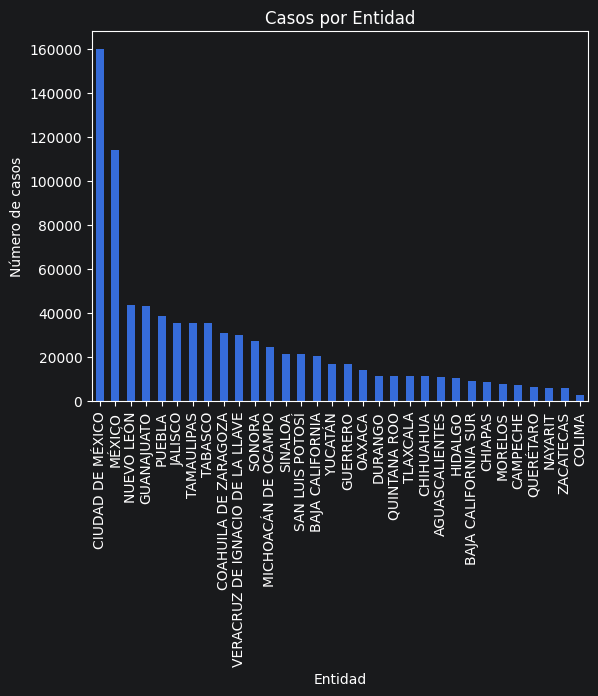

In [89]:
region_data = clean_df.groupby('entidad_federativa')['id_caso'] \
    .count() \
    .sort_values(ascending=False)

region_data.plot(
    kind='bar',
    title='Casos por Entidad',
    xlabel='Entidad',
    ylabel='Número de casos'
)

## Evolución de los casos de COVID a lo largo del tiempo

<Axes: title={'center': 'Evolución de casos COVID'}, xlabel='FECHA_INGRESO'>

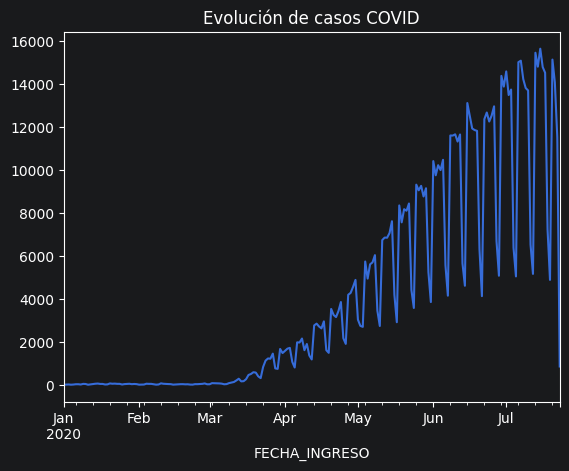

In [90]:
clean_df.groupby('FECHA_INGRESO')['id_caso'] \
    .count() \
    .sort_index() \
    .plot(
        kind='line',
        title='Evolución de casos COVID'
)

## Distribución de los casos de COVID según grupo de edad y resultado del diagnóstico

<Axes: title={'center': 'Casos COVID por edad y resultado'}, xlabel='grupo_edad'>

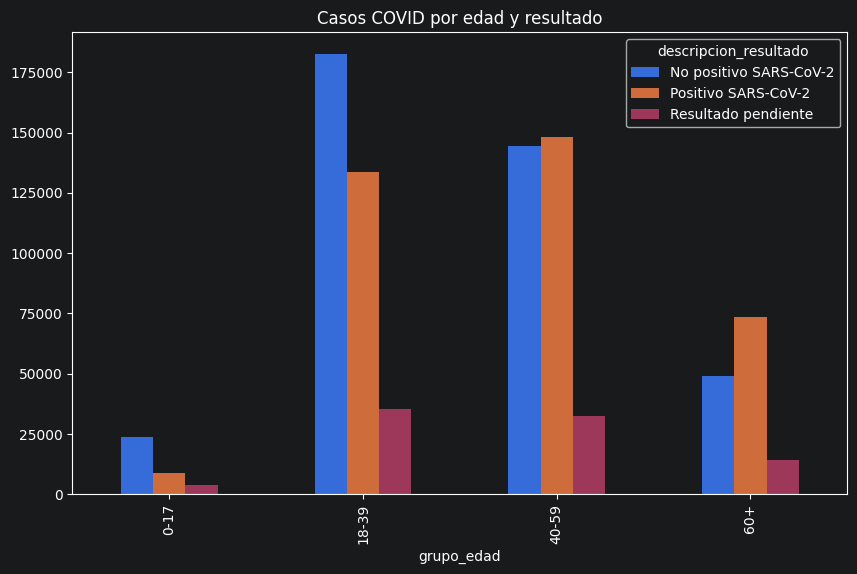

In [91]:
df_covid_clean.groupby(['grupo_edad','descripcion_resultado'])['id_caso'] \
    .count() \
    .unstack() \
    .plot(
        kind='bar',
        figsize=(10,6),
        title='Casos COVID por edad y resultado'
    )

## Distribución de los casos de COVID en las principales entidades según tipo de paciente

<Axes: title={'center': 'Top 5 entidades por tipo de paciente'}, xlabel='entidad_federativa'>

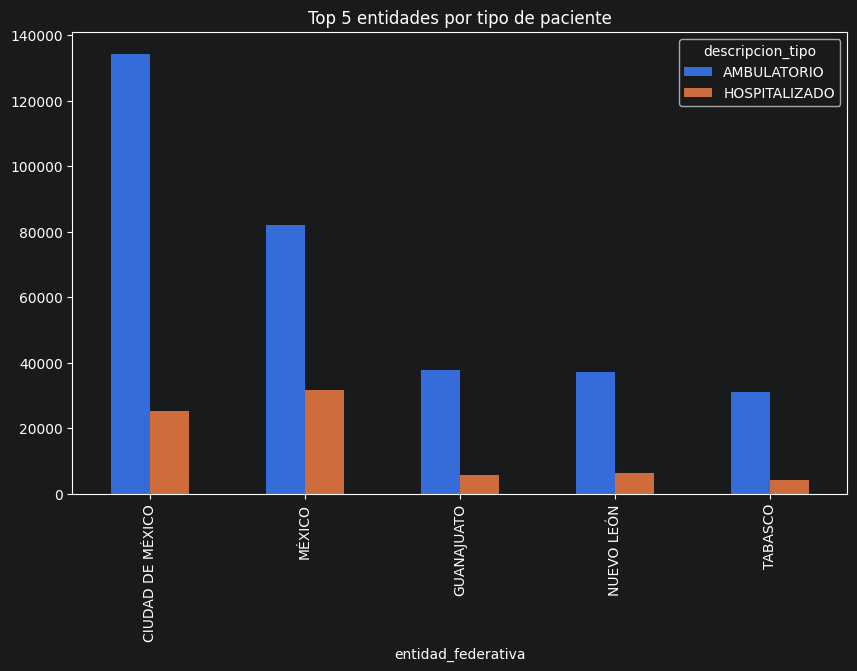

In [92]:
df_covid_clean.groupby(['entidad_federativa','descripcion_tipo'])['id_caso'] \
    .count() \
    .unstack() \
    .sort_values(by='AMBULATORIO', ascending=False) \
    .head(5) \
    .plot(
        kind='bar',
        figsize=(10,6),
        title='Top 5 entidades por tipo de paciente'
)

## Carga del Modelo de Estrella a AWS (target final)


In [ ]:
import boto3
import redshift_connector


En esta sección se realiza la conexión con los servicios de AWS, específicamente con Amazon S3 y Redshift, con el objetivo de cargar el modelo de estrella previamente construido.

Se configura el acceso mediante credenciales seguras y se establece la conexión con la base de datos en la nube. Esto permite transferir las tablas de hechos y dimensiones al entorno de almacenamiento, facilitando su utilización en consultas y análisis posteriores.

Esta etapa representa la integración final del proyecto, donde los datos preparados se trasladan a un entorno de producción para su explotación analítica.


In [ ]:
client = boto3.client(
    's3',
    aws_access_key_id=os.getenv('AWS_KEY_ID'),
    aws_secret_access_key=os.getenv('AWS_KEY')
)
conn = redshift_connector.connect(
    host=os.getenv('AWS_HOST'),
    database=os.getenv('AWS_DB'),
    port=5439,
    user=os.getenv('AWS_USR'),
    password=os.getenv('AWS_PASS')
)

cursor = conn.cursor()


En esta sección se define una función para automatizar la carga de los archivos del modelo estrella hacia AWS.

Primero, los archivos CSV son subidos al bucket de Amazon S3, permitiendo su almacenamiento en la nube. Posteriormente, se ejecuta una sentencia SQL de tipo COPY en Redshift, la cual permite cargar los datos desde S3 hacia las tablas correspondientes en la base de datos.

Este proceso se realiza de manera dinámica para cada archivo, facilitando la carga eficiente de la tabla de hechos y las dimensiones dentro del entorno analítico.


In [ ]:
def load_file(file_name):
    table_name = file_name.split('.')[0]
    client.upload_file(
        Filename="t2/{}".format(file_name),
        Bucket="proy3g4",
        Key="etl_t2/{}".format(file_name),
    )

    sentence = '''copy public.{} from 's3://proy3g4/etl_t2/{}' credentials 'aws_access_key_id={};aws_secret_access_key={}' csv delimiter '|' region 'sa-east-1' ignoreheader 1'''.format(
        table_name, file_name, os.getenv("AWS_KEY_ID"), os.getenv("AWS_KEY")
    )

    try:
        cursor.execute(sentence)
        print('ok tabla ' + table_name)
    except Exception as e:
        print('error en la tabla ' + e)

In [ ]:
load_file('covid.csv')

In [ ]:
load_file('entidad.csv')

In [ ]:
load_file('resultado.csv')

In [ ]:
load_file('sector.csv')

In [ ]:
load_file('sexo.csv')

In [ ]:
load_file('tipo.csv')

In [ ]:
conn.commit()

##  Bucket con archivos cargados


En esta sección se muestra el bucket de Amazon S3 utilizado para almacenar los archivos generados del modelo estrella.

Observamos los archivos correspondientes a la tabla de hechos (`covid.csv`) y las diferentes dimensiones (`entidad.csv`, `resultado.csv`, `sector.csv`, `sexo.csv`, `tipo.csv`), los cuales han sido cargados correctamente en la nube.

Este almacenamiento permite disponer de los datos en un entorno centralizado, facilitando su posterior carga hacia Redshift mediante el uso de comandos COPY para el análisis de la información.


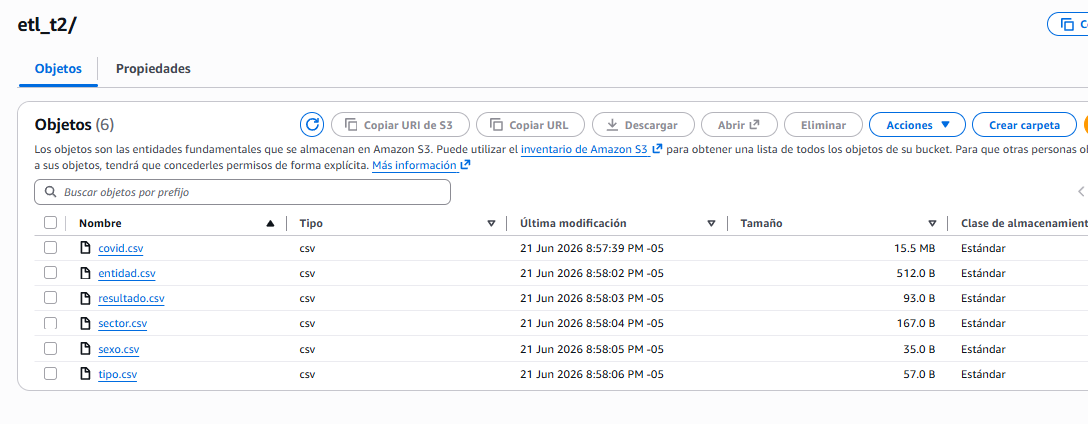

##  Estado de carga de la información al cluster de redshift

En esta sección validamos la ejecución de consultas en el clúster de Redshift, evidenciando que la carga del modelo estrella se ha realizado correctamente.

Mediante una consulta que integra la tabla de hechos con las dimensiones, se visualizan los datos completos de cada caso de COVID, incluyendo información como sexo, tipo de paciente, resultado y entidad.

El resultado obtenido confirma que los datos han sido cargados y estructurados adecuadamente, permitiendo su análisis dentro del entorno analítico en la nube.


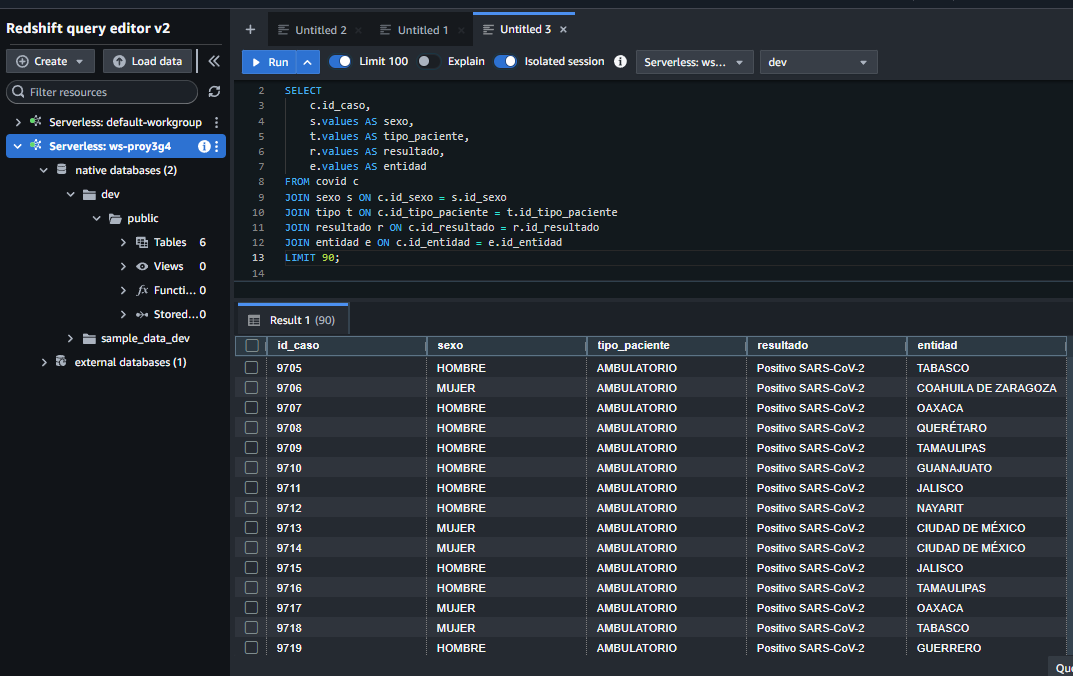

## Actividad Individual: Aplicación de la práctica en el entorno profesional


## Oscar Amagua

# Reflexión sobre la aplicación de los conocimientos adquiridos


Durante el desarrollo del proyecto pude darme cuenta de cómo los datos que al inicio se ven desordenados o complicados, pueden organizarse para que tengan sentido y sirvan para analizar información real. Al trabajar con el modelo estrella entendí mejor por qué no se deja todo en una sola tabla, sino que se separa en tabla de hechos y dimensiones, lo cual al inicio me confundía bastante, pero luego vi que facilita mucho las consultas.

También fue clave el uso de herramientas como AWS S3 y Redshift, ya que no solo trabajé con datos en local, sino que pude experimentar cómo se manejan en un entorno en la nube. Esto me ayudó a ver cómo este tipo de procesos se aplican realmente en un contexto profesional.

Durante proceso, más allá del código, entendí que lo importante es la lógica detrás de cómo se estructuran los datos y cómo se logra que la información sea clara al momento de hacer consultas. En general, siento que este proyecto me ayudó a entender mejor el flujo completo de trabajo con datos, desde la limpieza hasta el análisis, y cómo todo está conectado.


## Rafael Espinosa

# Reflexión sobre la aplicación de los conocimientos adquiridos

### Aplicación del proceso de Carga (Load) del ETL en mi entorno laboral

Como profesional del área de Sistemas, Gestión de Proyectos y Ciberseguridad, considero que la fase de **Carga (Load)** del proceso ETL es fundamental para garantizar que la información transformada llegue de manera segura, consistente y oportuna a los sistemas de destino donde será utilizada para la toma de decisiones.

En mi entorno laboral, un caso práctico de aplicación se presenta en una institución financiera. Estas organizaciones manejan grandes volúmenes de información provenientes de múltiples fuentes, como sistemas transaccionales, aplicaciones web, plataformas de atención al cliente, sistemas de créditos y bases de datos externas. Cada una de estas fuentes genera datos con diferentes formatos y estructuras, por lo que es necesario consolidarlos para obtener una visión integral del negocio.

Una vez ejecutadas las fases de extracción y transformación, la etapa de carga consiste en almacenar los datos procesados en un repositorio central, generalmente un Data Warehouse o un Data Mart especializado. Por ejemplo, supongamos que diariamente se recopilan registros de solicitudes de crédito, pagos realizados por los clientes y movimientos de cuentas bancarias. Después de limpiar, validar y estandarizar estos datos, la fase de carga los inserta en las tablas del almacén de datos corporativo.

Para implementar este proceso utilizaría herramientas como Pentaho Data Integration, SQL Server Integration Services (SSIS) o Apache Airflow, dependiendo de la infraestructura tecnológica disponible. La carga podría ejecutarse de manera programada durante horarios de baja actividad, minimizando el impacto sobre los sistemas operacionales. Asimismo, se establecerían mecanismos de control para verificar que la totalidad de los registros transformados hayan sido cargados correctamente y sin pérdidas de información.

Desde la perspectiva de gestión de proyectos, esta etapa requiere definir políticas de monitoreo, indicadores de calidad y procedimientos de recuperación ante fallos. Por ejemplo, si durante la carga se detecta una inconsistencia en los datos o una interrupción del servicio, el proceso debe contar con mecanismos automáticos de reintento y generación de alertas para los equipos responsables.

Por otro lado, desde el enfoque de ciberseguridad, es indispensable garantizar la protección de la información durante la carga. Para ello implementaría controles de acceso basados en roles, cifrado de datos sensibles, auditoría de operaciones y trazabilidad completa de los registros procesados. De esta forma se asegura el cumplimiento de normativas de seguridad y protección de datos.

Finalmente, una vez completada la carga, los datos quedan disponibles para herramientas de inteligencia de negocios, cuadros de mando y procesos analíticos que apoyan la toma de decisiones estratégicas. Gracias a este proceso, la organización puede generar reportes confiables sobre indicadores financieros, comportamiento de clientes, riesgos crediticios y desempeño operativo.

En conclusión, la fase de carga del ETL representa el paso que convierte los datos transformados en información útil para la organización. Su correcta implementación permite disponer de información íntegra, segura y actualizada, facilitando el análisis de datos y mejorando la capacidad de respuesta de la empresa frente a los desafíos del negocio.


## Cristian González

# Reflexión sobre la aplicación de los conocimientos adquiridos

Durante esta semana comprendí mejor la importancia de la fase de carga dentro de un proceso ETL y cómo esta permite disponer de información organizada para su posterior análisis. También entendí de mejor manera la función de las dimensiones y las tablas de hechos dentro de un modelo estrella.

El uso de herramientas en la nube como Amazon S3 y Redshift me permitió conocer cómo se puede almacenar y gestionar información para realizar análisis de datos de forma más eficiente, las visualizaciones realizadas ayudaron a comprender cómo los datos pueden transformarse en información útil para apoyar la toma de decisiones.
En general, esta práctica fortaleció mis conocimientos sobre integración, almacenamiento y análisis de datos, permitiéndome comprender mejor el flujo completo de un proceso ETL.
